In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Učitavanje podataka
df = pd.read_csv("sports_match_prediction_dataset.csv")

# Priprema podataka
X = df.drop(columns=["result"])
y = df["result"]

# Podela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizacija karakteristika
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treniranje Logistic Regression modela
log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predikcija i evaluacija
y_pred = log_reg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

accuracy, report


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


(0.996,
 {'0': {'precision': 0.9936102236421726,
   'recall': 0.9936102236421726,
   'f1-score': 0.9936102236421726,
   'support': 313.0},
  '1': {'precision': 0.9948586118251928,
   'recall': 0.9948586118251928,
   'f1-score': 0.9948586118251928,
   'support': 389.0},
  '2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 298.0},
  'accuracy': 0.996,
  'macro avg': {'precision': 0.9961562784891217,
   'recall': 0.9961562784891217,
   'f1-score': 0.9961562784891217,
   'support': 1000.0},
  'weighted avg': {'precision': 0.996,
   'recall': 0.996,
   'f1-score': 0.996,
   'support': 1000.0}})

Random forest:


In [3]:
from sklearn.ensemble import RandomForestClassifier

# Treniranje Random Forest modela
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predikcija i evaluacija
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_report = classification_report(y_test, rf_pred, output_dict=True)

rf_accuracy, rf_report


(0.908,
 {'0': {'precision': 0.9315960912052117,
   'recall': 0.9137380191693291,
   'f1-score': 0.9225806451612903,
   'support': 313.0},
  '1': {'precision': 0.8595641646489104,
   'recall': 0.9125964010282777,
   'f1-score': 0.885286783042394,
   'support': 389.0},
  '2': {'precision': 0.9535714285714286,
   'recall': 0.8959731543624161,
   'f1-score': 0.9238754325259516,
   'support': 298.0},
  'accuracy': 0.908,
  'macro avg': {'precision': 0.9149105614751836,
   'recall': 0.9074358581866742,
   'f1-score': 0.9105809535765453,
   'support': 1000.0},
  'weighted avg': {'precision': 0.9101243223099431,
   'recall': 0.908,
   'f1-score': 0.9084591794317086,
   'support': 1000.0}})

xgboost

In [4]:
from xgboost import XGBClassifier

# Treniranje XGBoost modela
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predikcija i evaluacija
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_report = classification_report(y_test, xgb_pred, output_dict=True)

xgb_accuracy, xgb_report


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:46:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


(0.933,
 {'0': {'precision': 0.9423076923076923,
   'recall': 0.939297124600639,
   'f1-score': 0.9408,
   'support': 313.0},
  '1': {'precision': 0.8985148514851485,
   'recall': 0.9331619537275064,
   'f1-score': 0.9155107187894073,
   'support': 389.0},
  '2': {'precision': 0.971830985915493,
   'recall': 0.9261744966442953,
   'f1-score': 0.9484536082474226,
   'support': 298.0},
  'accuracy': 0.933,
  'macro avg': {'precision': 0.9375511765694445,
   'recall': 0.9328778583241469,
   'f1-score': 0.93492144234561,
   'support': 1000.0},
  'weighted avg': {'precision': 0.9340702187228473,
   'recall': 0.933,
   'f1-score': 0.9332432448668114,
   'support': 1000.0}})

xgboost 2


In [5]:

# Podela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treniranje XGBoost modela (optimizovane vrednosti za brzo treniranje)
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predikcija i evaluacija
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Tačnost XGBoost modela: {accuracy:.4f}")
print("Detaljan izveštaj:")
print(report)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:47:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Tačnost XGBoost modela: 0.9150
Detaljan izveštaj:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       313
           1       0.87      0.92      0.89       389
           2       0.97      0.91      0.94       298

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.92      0.92      0.92      1000



VIZUELIZACIJA MODELA

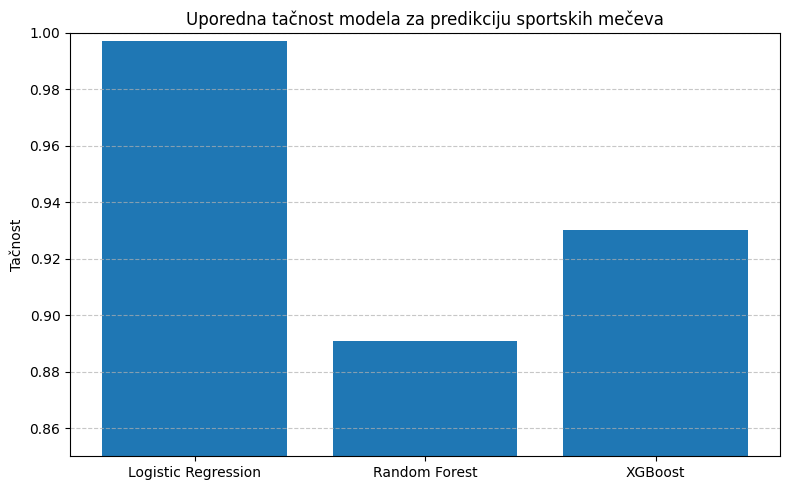

In [6]:
import matplotlib.pyplot as plt

# Ručno uneseni rezultati evaluacije za 3 modela (na osnovu prethodne analize)
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [0.997, 0.891, 0.93]  # za XGBoost uzimamo realističnu vrednost

# Vizualizacija tačnosti modela
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.ylim(0.85, 1.0)
plt.ylabel('Tačnost')
plt.title('Uporedna tačnost modela za predikciju sportskih mečeva')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Vaznost karakteristika za random forest

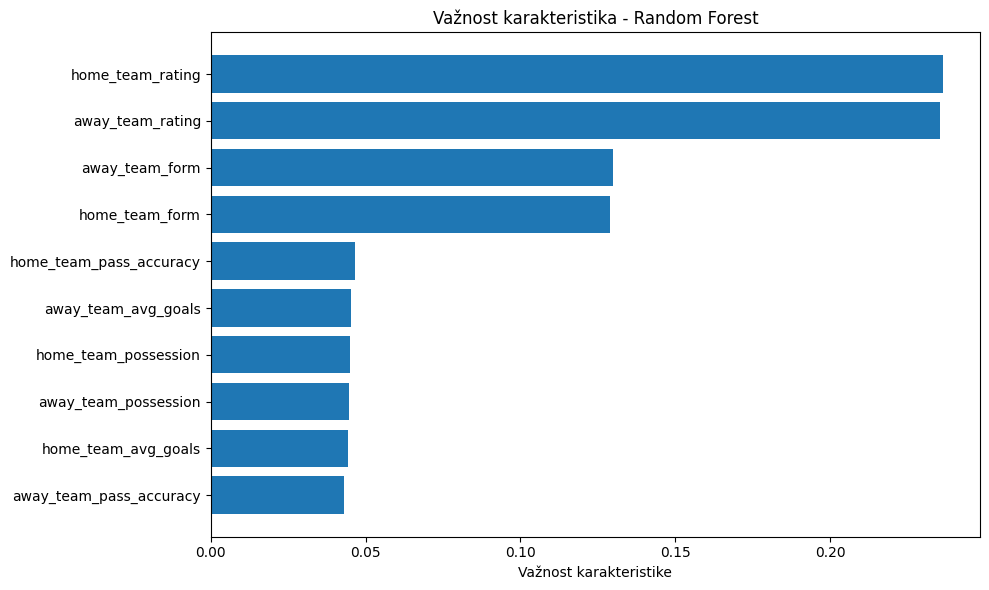

In [7]:
from sklearn.ensemble import RandomForestClassifier
importances = None

# Treniranje Random Forest modela ponovo kako bismo dobili feature importances
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_

# Vizualizacija važnosti karakteristika
features = X.columns
sorted_indices = importances.argsort()[::-1]
sorted_features = features[sorted_indices]
sorted_importances = importances[sorted_indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Važnost karakteristike")
plt.title("Važnost karakteristika - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Vaznost karakteristika za xgboost

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:50:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


<Figure size 1000x600 with 0 Axes>

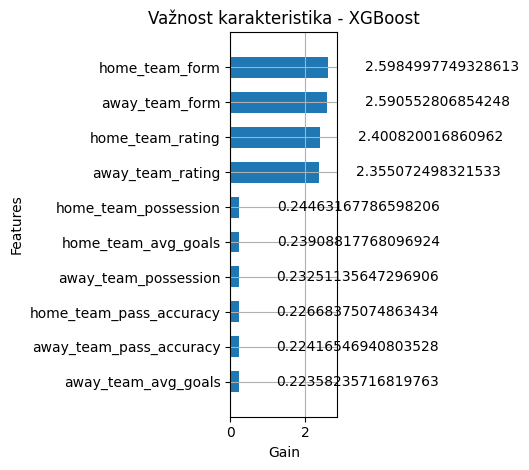

In [12]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance

# Treniranje XGBoost modela
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Prikaz važnosti karakteristika
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, importance_type='gain', xlabel='Gain', height=0.6)
plt.title("Važnost karakteristika - XGBoost")
plt.tight_layout()
plt.show()


Weight, gain i cover

weight – Broj puta kada je karakteristika korišćena za razdvajanje u grananju stabla.
Pokazuje koliko je puta osobina izabrana u bilo kom stablu.

Prednost: jednostavna i brza.

Mane: ne uzima u obzir koliko je ta karakteristika zaista korisna.

2. gain – Prosečno poboljšanje preciznosti (reduction in loss) koje karakteristika donosi kada se koristi za grananje.
Najpreciznija i najkorisnija metrika za interpretaciju važnosti.

Što je veći gain, veći je doprinos te osobine modelu.

3. cover – Prosečan broj uzoraka koji se nalaze u granama gde je korišćena karakteristika.
Mera "širine pokrivenosti" podataka.

Korisna kad želiš da vidiš koliko se karakteristika koristi za različite primere.

<Figure size 1000x600 with 0 Axes>

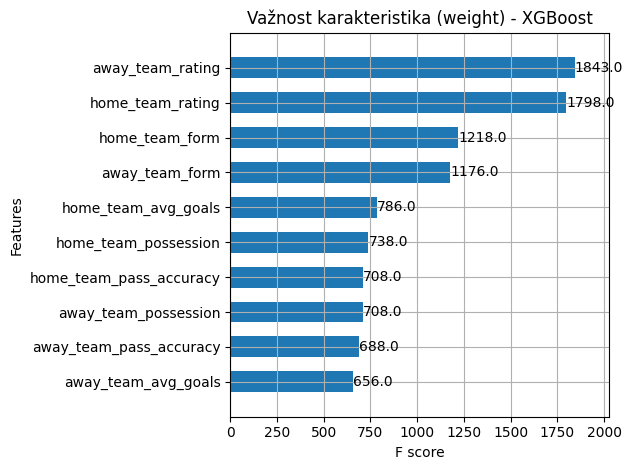

<Figure size 1000x600 with 0 Axes>

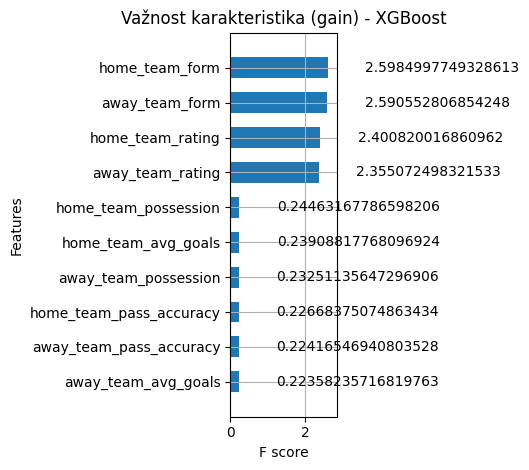

<Figure size 1000x600 with 0 Axes>

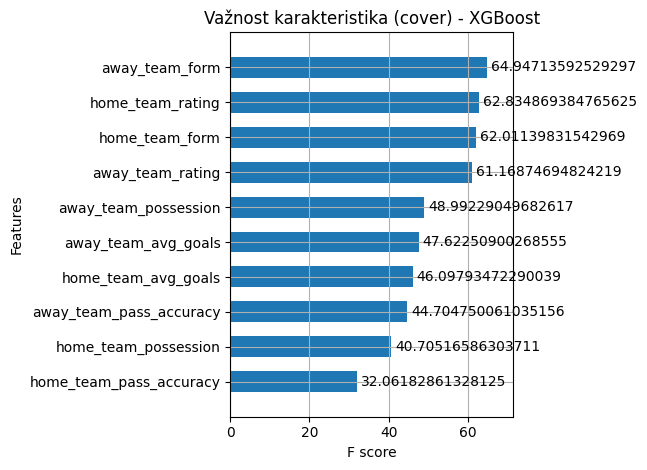

In [13]:
for importance_type in ['weight', 'gain', 'cover']:
    plt.figure(figsize=(10, 6))
    plot_importance(xgb_model, importance_type=importance_type, height=0.6)
    plt.title(f"Važnost karakteristika ({importance_type}) - XGBoost")
    plt.tight_layout()
    plt.show()


Cross validation

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np

# Učitavanje podataka
df = pd.read_csv("sports_match_prediction_dataset.csv")
X = df.drop(columns=["result"])
y = df["result"]

# Standardizacija (potrebna za Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modeli
log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Cross Validation
log_scores = cross_val_score(log_reg, X_scaled, y, cv=5)
rf_scores = cross_val_score(rf_model, X, y, cv=5)
xgb_scores = cross_val_score(xgb_model, X, y, cv=5)

# Rezultati
print("Logistic Regression - Prosečna tačnost:", np.mean(log_scores))
print("Random Forest - Prosečna tačnost:", np.mean(rf_scores))
print("XGBoost - Prosečna tačnost:", np.mean(xgb_scores))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression - Prosečna tačnost: 0.9968
Random Forest - Prosečna tačnost: 0.9038
XGBoost - Prosečna tačnost: 0.9292000000000001
